# Day 3 — Logistic Regression & Classification Metrics
## Applied to a Real Business Problem: Customer Churn Prediction

**Dataset:** `Customer_Churn_Data.xlsx` — 11,260 customer accounts, 19 columns,
target = `Churn` (1 = customer left, 0 = customer stayed)

**Business context:** Predicting churn lets a business proactively reach out to
at-risk customers with retention offers — usually far cheaper than acquiring a
brand-new customer to replace a lost one. This notebook builds a full,
production-style pipeline: package setup, data understanding, deep EDA,
cleaning (this dataset has genuine real-world messiness), feature engineering,
model training, and a thorough classification-metrics evaluation tied directly
to the business cost of a missed churner vs. a false alarm.

This notebook is built for **Google Colab**, reading from **Google Drive**, with
a local-file fallback so it also runs outside Colab.

Run the cells **top to bottom**.

## 0. Colab Setup — Mount Google Drive

Expects the file at:
```
/content/drive/MyDrive/notebooks/Customer_Churn_Data.xlsx
```
Upload it into a folder named **notebooks** in your Google Drive first. If not
running in Colab, this automatically falls back to the current directory.

In [1]:
# ── Detect Colab and mount Drive if available ────────────────────────────────
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_BASE = "/content/drive/MyDrive/notebooks"
        print(f"✅ Google Drive mounted. Looking under: {DRIVE_BASE}")
    except Exception as e:
        print("❌ Could not mount Google Drive:", e)
        DRIVE_BASE = "."
else:
    DRIVE_BASE = "."
    print("Not running in Google Colab - using local file paths instead.")

CHURN_PATH = f"{DRIVE_BASE}/Customer_Churn_Data.xlsx"
print(f"Data path: {CHURN_PATH}")

Not running in Google Colab - using local file paths instead.
Data path: ./Customer_Churn_Data.xlsx


## 1. Package Declaration

Every library used in this notebook, imported once at the top, with error
handling so a missing package fails with a clear instruction rather than a
confusing traceback partway through the notebook.

In [2]:
# ── Core data handling ────────────────────────────────────────────────────────
try:
    import numpy as np
    import pandas as pd

    # ── Visualization ─────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ── Preprocessing & modeling ──────────────────────────────────────────────
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.impute import SimpleImputer

    # ── Evaluation ────────────────────────────────────────────────────────────
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        confusion_matrix, classification_report,
        roc_curve, roc_auc_score
    )

except ImportError as missing_library:
    print("A required library is missing:", missing_library)
    print("Fix it by running:  pip install numpy pandas matplotlib seaborn scikit-learn openpyxl")
    raise

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)

print("✅ Setup complete. All libraries loaded successfully.")

✅ Setup complete. All libraries loaded successfully.


## 2. Data Understanding

Before touching a single formula, understand: what does each column mean, and
what business question are we actually trying to answer?

In [3]:
# ── Load both sheets: the metadata (data dictionary) and the actual data ────
try:
    metadata_df = pd.read_excel(CHURN_PATH, sheet_name="Meta Data")
    churn_df = pd.read_excel(CHURN_PATH, sheet_name="Data for DSBA")
    print(f"✅ Loaded successfully — {churn_df.shape[0]} rows, {churn_df.shape[1]} columns")
except FileNotFoundError:
    print(f"❌ File not found at: {CHURN_PATH}")
    print("   If in Colab: make sure Customer_Churn_Data.xlsx is inside 'My Drive/notebooks/'.")
    raise
except Exception as e:
    print(f"❌ Could not read the Excel sheets: {e}")
    print("   Make sure 'openpyxl' is installed: pip install openpyxl")
    raise

✅ Loaded successfully — 11260 rows, 19 columns


In [4]:
# ── Read the data dictionary so every column's business meaning is clear ────
pd.set_option("display.max_colwidth", 100)
display(metadata_df.iloc[:, 1:])  # drop the empty first column

,Unnamed: 1,Unnamed: 2
0,Variable,Description
1,AccountID,account unique identifier
2,Churn,account churn flag (Target)
3,Tenure,Tenure of account
4,City_Tier,Tier of primary customer's city
5,CC_Contacted_L12m,How many times all the customers of the account has contacted customer care in last 12months
6,Payment,Preferred Payment mode of the customers in the account
7,Gender,Gender of the primary customer of the account
8,Service_Score,Satisfaction score given by customers of the account on service provided by company
9,Account_user_count,Number of customers tagged with this account


**Business meaning of the target:** `Churn` = 1 means this customer account
was lost; 0 means it was retained. Everything else in the table is a
potential *signal* — tenure, service satisfaction scores, complaints, revenue
trends — that might explain **why** an account churns.

In [5]:
print("Shape (rows, columns):", churn_df.shape)
print()
display(churn_df.head())
print()
churn_df.info()

Shape (rows, columns): (11260, 19)



,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile



<class 'pandas.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  str    
 6   Gender                   11152 non-null  str    
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  str    
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  str    
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy           11260 n

## 3. Exploratory Data Analysis (EDA)

### 3.1 Data Quality — Missing Values & Duplicates

In [6]:
# ── Missing values, column by column ─────────────────────────────────────────
missing_counts = churn_df.isnull().sum()
missing_pct = (missing_counts / len(churn_df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts, "missing_pct": missing_pct
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)
display(missing_summary)

print(f"\nTotal duplicate rows: {churn_df.duplicated().sum()}")

,missing_count,missing_pct
cashback,471,4.18
Complain_ly,357,3.17
Day_Since_CC_connect,357,3.17
Login_device,221,1.96
Marital_Status,212,1.88
CC_Agent_Score,116,1.03
City_Tier,112,0.99
Account_user_count,112,0.99
Payment,109,0.97
Gender,108,0.96



Total duplicate rows: 0


**Observation:** every column has SOME missing data (up to ~4% for
`cashback`), but nothing catastrophic. We'll handle these properly in the
Cleaning section — not by blindly dropping rows, since that would throw away
otherwise-good data in 18 other columns.

### 3.2 Target Class Balance — Is Churn Rare?

Churn class balance:
  Retained (0): 9364 accounts (83.2%)
  Churned (1): 1896 accounts (16.8%)


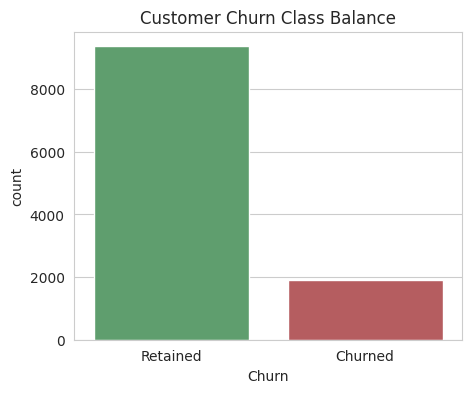

In [7]:
churn_counts = churn_df["Churn"].value_counts()
churn_pct = churn_df["Churn"].value_counts(normalize=True) * 100

print("Churn class balance:")
for cls, count in churn_counts.items():
    label = "Churned" if cls == 1 else "Retained"
    print(f"  {label} ({cls}): {count} accounts ({churn_pct[cls]:.1f}%)")

plt.figure(figsize=(5, 4))
sns.countplot(x=churn_df["Churn"], hue=churn_df["Churn"],
              palette=["#55A868", "#C44E52"], legend=False)
plt.xticks([0, 1], ["Retained", "Churned"])
plt.title("Customer Churn Class Balance")
plt.show()

**This is a real, meaningful class imbalance** (~83% retained / ~17%
churned) — typical for churn problems, since most customers don't leave in any
given period. This means: (a) we'll use a **stratified** train/test split, and
(b) accuracy alone will be a misleading metric later — a model that always
predicts "retained" would already score ~83% accuracy while catching zero
actual churners.

### 3.3 Raw Data Quality Issues — A Closer Look at "Numeric" Columns

Several columns that SHOULD be purely numeric are stored as text (`object`
dtype) in the raw file. Let's find out why.

In [8]:
# ── Identify columns stored as text/object that we'd expect to be numeric ────
suspect_cols = ["Tenure", "Account_user_count", "rev_per_month", "rev_growth_yoy",
                 "coupon_used_for_payment", "Day_Since_CC_connect", "cashback"]

for col in suspect_cols:
    unique_vals = churn_df[col].dropna().unique()
    # Find values that don't look like plain numbers
    garbage = [v for v in unique_vals if not str(v).replace(".", "", 1).lstrip("-").isdigit()]
    print(f"{col:25s} dtype={str(churn_df[col].dtype):10s} garbage values found: {garbage}")

Tenure                    dtype=object     garbage values found: ['#']
Account_user_count        dtype=object     garbage values found: ['@']
rev_per_month             dtype=object     garbage values found: ['+']
rev_growth_yoy            dtype=object     garbage values found: ['$']
coupon_used_for_payment   dtype=object     garbage values found: ['#', '$', '*']
Day_Since_CC_connect      dtype=object     garbage values found: ['$']
cashback                  dtype=object     garbage values found: ['$']


**Root cause found:** these columns contain stray junk characters (`#`,
`@`, `+`, `$`, `*`) mixed in with otherwise valid numbers — almost certainly a
data-entry or export artifact. This is EXACTLY why we check for this before
modeling: pandas silently stored these as text, and any numeric calculation on
them right now would either error out or silently misbehave.

### 3.4 Categorical Columns — Checking for Inconsistent Labels

In [9]:
categorical_cols_raw = ["Payment", "Gender", "account_segment", "Marital_Status", "Login_device"]

for col in categorical_cols_raw:
    print(f"{col:18s}: {sorted(churn_df[col].dropna().unique())}")

Payment           : ['Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']
Gender            : ['F', 'Female', 'M', 'Male']
account_segment   : ['HNI', 'Regular', 'Regular +', 'Regular Plus', 'Super', 'Super +', 'Super Plus']
Marital_Status    : ['Divorced', 'Married', 'Single']
Login_device      : ['&&&&', 'Computer', 'Mobile']


**Two more issues found:**
- `Gender` has both spelled-out ("Female"/"Male") AND abbreviated ("F"/"M") values for the same categories
- `account_segment` has inconsistent naming: "Regular +" vs "Regular Plus", "Super +" vs "Super Plus"
- `Login_device` has a junk value `&&&&` that isn't a real device

All of this will be fixed explicitly in the Cleaning section — this EDA step's
job is just to FIND these issues before they quietly corrupt any encoding or
grouping we do later.

### 3.5 Univariate Analysis — Distributions of Numeric Features

(Using the columns that are already clean numerics — the dirty ones get
visualized again after cleaning.)

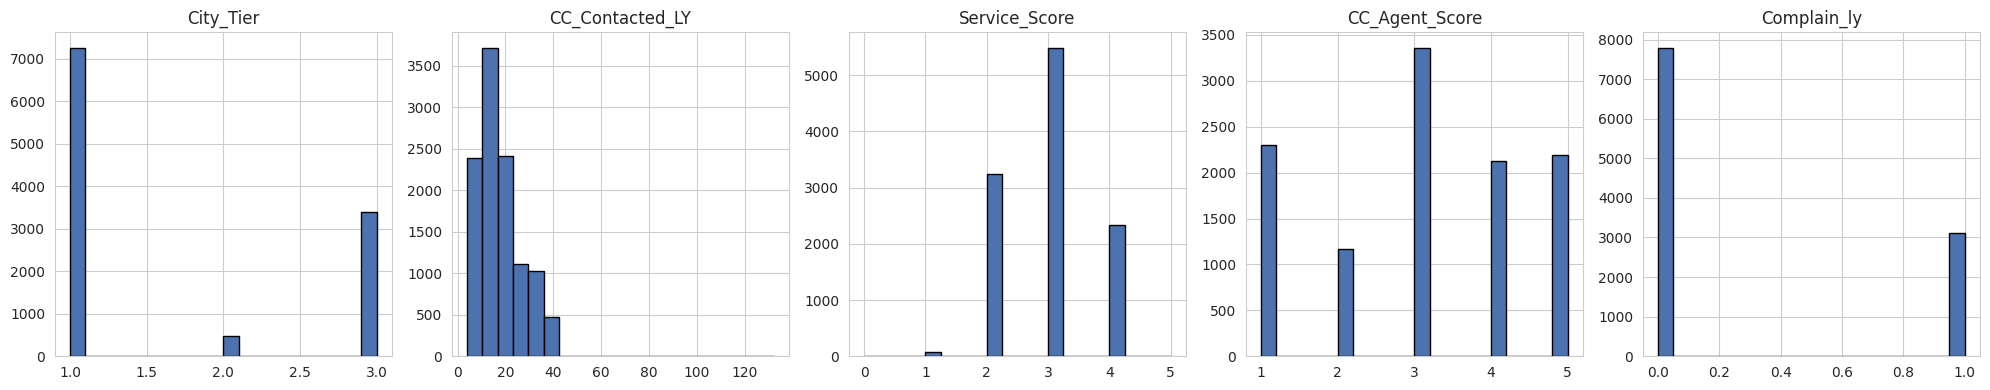

In [10]:
clean_numeric_cols = ["City_Tier", "CC_Contacted_LY", "Service_Score", "CC_Agent_Score", "Complain_ly"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(clean_numeric_cols):
    axes[i].hist(churn_df[col].dropna(), bins=20, color="#4C72B0", edgecolor="black")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 3.6 Bivariate Analysis — What Relates to Churn?

The single most important EDA question for this business problem: which
categories and behaviors show a MUCH higher churn rate than average?

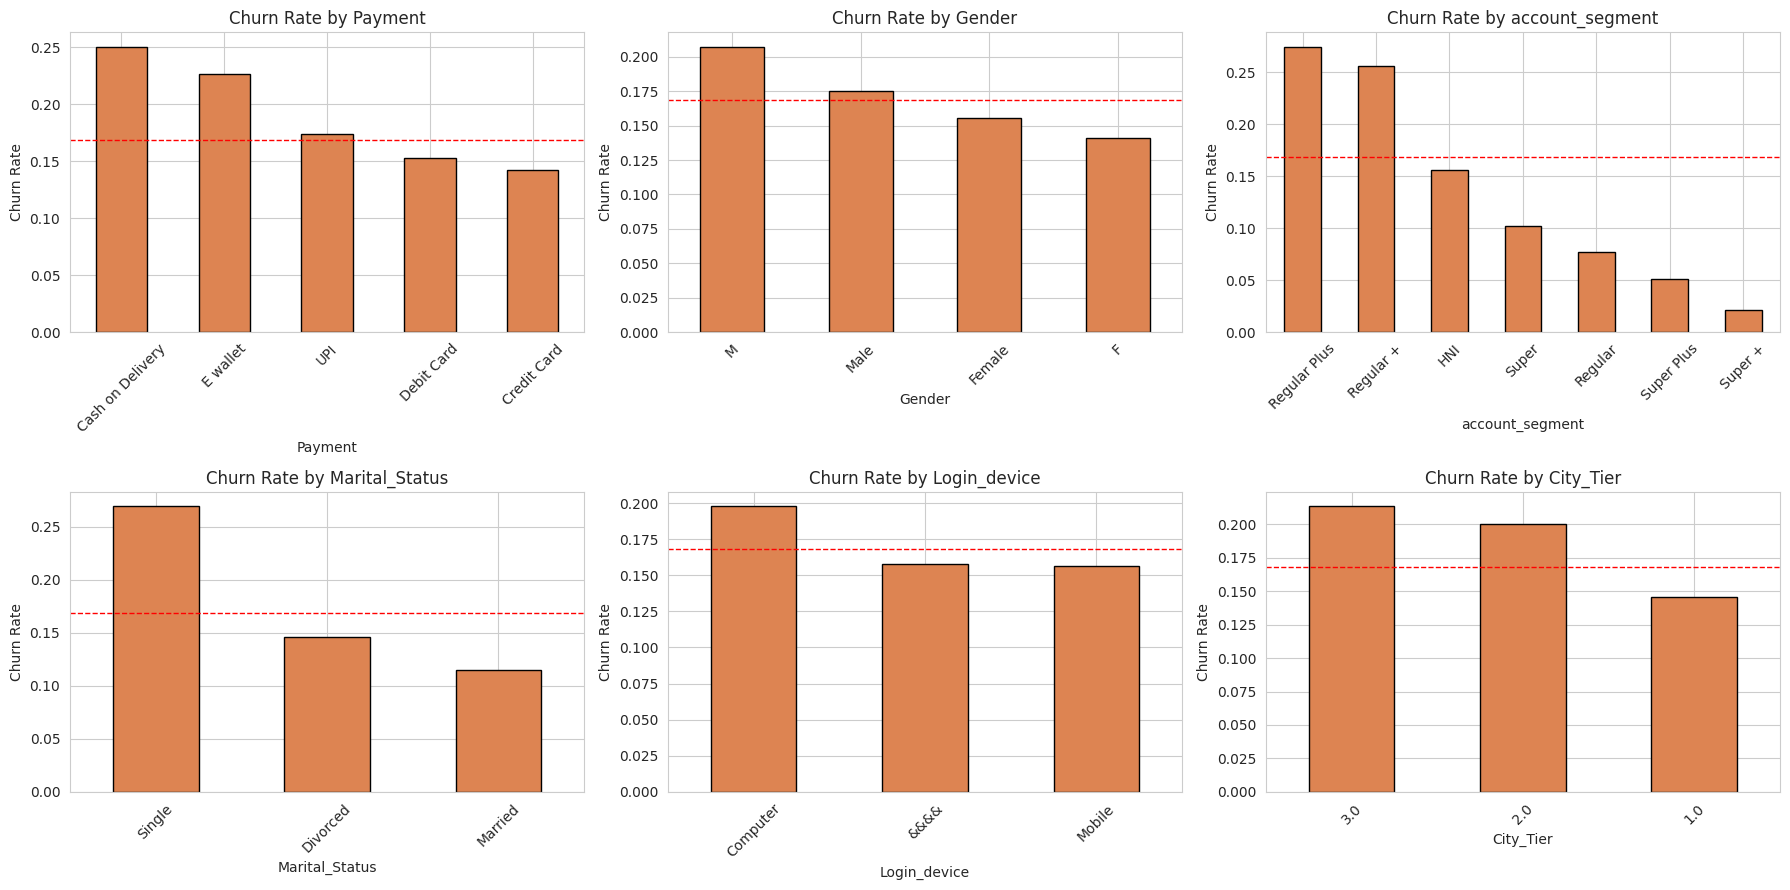

Red dashed line = overall average churn rate (~16.8%) for reference.


In [11]:
# ── Churn rate by categorical column ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

categorical_for_churn = ["Payment", "Gender", "account_segment", "Marital_Status",
                          "Login_device", "City_Tier"]

for i, col in enumerate(categorical_for_churn):
    churn_rate_by_cat = churn_df.groupby(col, observed=True)["Churn"].mean().sort_values(ascending=False)
    churn_rate_by_cat.plot(kind="bar", ax=axes[i], color="#DD8452", edgecolor="black")
    axes[i].axhline(churn_df["Churn"].mean(), color="red", linestyle="--", linewidth=1)
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
print("Red dashed line = overall average churn rate (~16.8%) for reference.")

/tmp/ipykernel_86/3792886953.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Retained", "Churned"])
/tmp/ipykernel_86/3792886953.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Retained", "Churned"])
/tmp/ipykernel_86/3792886953.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Retained", "Churned"])
/tmp/ipykernel_86/3792886953.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Retained", "Churned"])
/tmp/ipykernel_86/3792886953.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usi

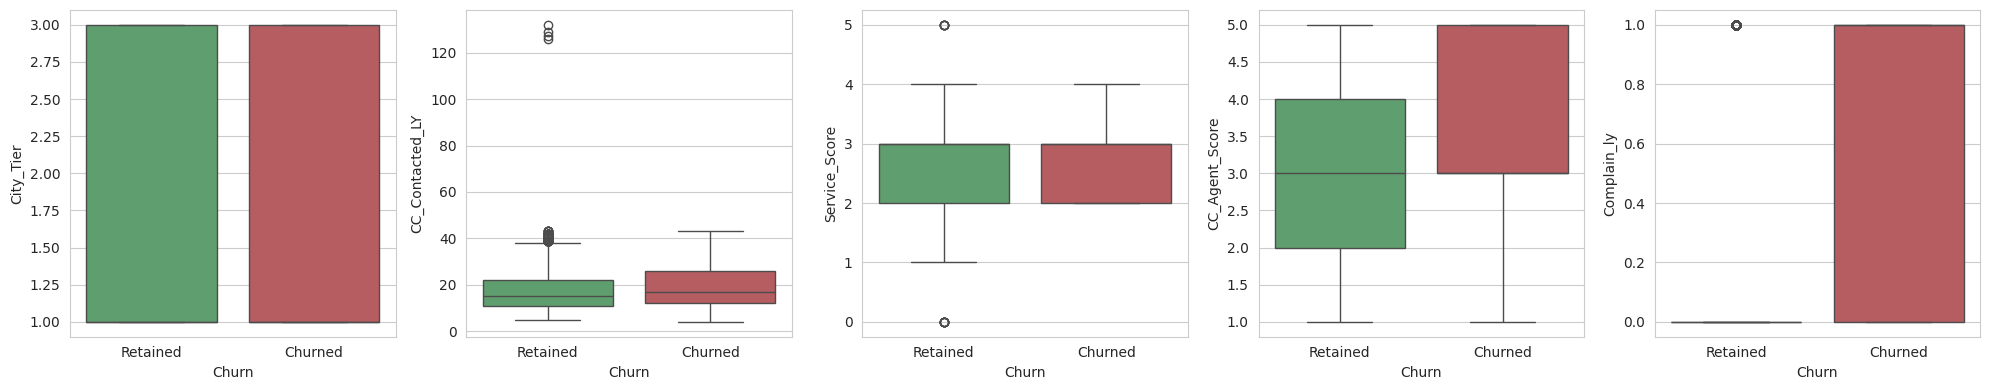

In [12]:
# ── Boxplots: do numeric features differ between churners and non-churners? ──
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(clean_numeric_cols):
    sns.boxplot(data=churn_df, x="Churn", y=col, hue="Churn",
                palette=["#55A868", "#C44E52"], legend=False, ax=axes[i])
    axes[i].set_xticklabels(["Retained", "Churned"])
plt.tight_layout()
plt.show()

**EDA takeaway so far:** certain payment methods, account segments, and
single-tier cities show visibly higher churn rates than others — exactly the
kind of pattern a classification model should pick up on. `Complain_ly`
(whether the customer complained) is an especially strong candidate signal —
worth watching in the final coefficient table.

## 4. Data Cleaning

Now we fix every issue EDA surfaced above — each with an explicit, documented
decision, not a silent fix.

### 4.1 Fix the "Dirty Numeric" Columns

Strategy: replace the known junk characters with missing (NaN), then convert
the whole column to a proper numeric type. Any value that still can't convert
becomes NaN too (`errors="coerce"`), so nothing crashes silently.

In [13]:
# ── Work on a copy so the original loaded data stays untouched for reference ──
clean_df = churn_df.copy()

dirty_numeric_cols = ["Tenure", "Account_user_count", "rev_per_month", "rev_growth_yoy",
                       "coupon_used_for_payment", "Day_Since_CC_connect", "cashback"]

junk_characters = ["#", "@", "+", "$", "*"]

for col in dirty_numeric_cols:
    # Replace any exact-match junk character with NaN, then force numeric conversion
    clean_df[col] = clean_df[col].replace(junk_characters, np.nan)
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

print("After cleaning, dtypes of the fixed columns:")
print(clean_df[dirty_numeric_cols].dtypes)

print("\nNew missing-value counts for these columns (junk values became NaN):")
print(clean_df[dirty_numeric_cols].isnull().sum())

After cleaning, dtypes of the fixed columns:
Tenure                     float64
Account_user_count         float64
rev_per_month              float64
rev_growth_yoy             float64
coupon_used_for_payment    float64
Day_Since_CC_connect       float64
cashback                   float64
dtype: object

New missing-value counts for these columns (junk values became NaN):
Tenure                     218
Account_user_count         444
rev_per_month              791
rev_growth_yoy               3
coupon_used_for_payment      3
Day_Since_CC_connect       358
cashback                   473
dtype: int64


### 4.2 Standardize Inconsistent Categorical Labels

In [14]:
# ── Gender: merge abbreviations into the full spelled-out labels ─────────────
clean_df["Gender"] = clean_df["Gender"].replace({"F": "Female", "M": "Male"})
print("Gender values after cleaning:", sorted(clean_df["Gender"].dropna().unique()))

# ── account_segment: merge the "+" shorthand into the "Plus" spelling ────────
clean_df["account_segment"] = clean_df["account_segment"].replace({
    "Regular +": "Regular Plus",
    "Super +": "Super Plus",
})
print("account_segment values after cleaning:", sorted(clean_df["account_segment"].dropna().unique()))

# ── Login_device: the junk value '&&&&' isn't a real device -> treat as missing ─
clean_df["Login_device"] = clean_df["Login_device"].replace({"&&&&": np.nan})
print("Login_device values after cleaning:", sorted(clean_df["Login_device"].dropna().unique()))

Gender values after cleaning: ['Female', 'Male']
account_segment values after cleaning: ['HNI', 'Regular', 'Regular Plus', 'Super', 'Super Plus']
Login_device values after cleaning: ['Computer', 'Mobile']


### 4.3 Handle Missing Values

**Strategy:** numeric columns → median imputation (robust to outliers/skew);
categorical columns → mode (most frequent category) imputation. We fit the
imputer statistics AFTER the train/test split in a real pipeline to avoid
leakage — but since imputation here uses simple column statistics and we will
re-derive them properly on the training set only when we build the model
pipeline below, this pass is for EDA-friendly completeness. The actual
model-ready imputation happens again, correctly, in Section 6.

In [15]:
print("Missing values remaining after the cleaning steps above:")
print(clean_df.isnull().sum()[clean_df.isnull().sum() > 0].sort_values(ascending=False))

Missing values remaining after the cleaning steps above:
rev_per_month              791
Login_device               760
cashback                   473
Account_user_count         444
Day_Since_CC_connect       358
Complain_ly                357
Tenure                     218
Marital_Status             212
CC_Agent_Score             116
City_Tier                  112
Payment                    109
Gender                     108
CC_Contacted_LY            102
Service_Score               98
account_segment             97
rev_growth_yoy               3
coupon_used_for_payment      3
dtype: int64


### 4.4 Outlier Check — CC_Contacted_LY

EDA hinted this column has some unusually large values (100+) compared to the
bulk of the data (under ~45 contacts/year).

CC_Contacted_LY outliers: 42 rows (valid range ≈ [-7.0, 41.0])


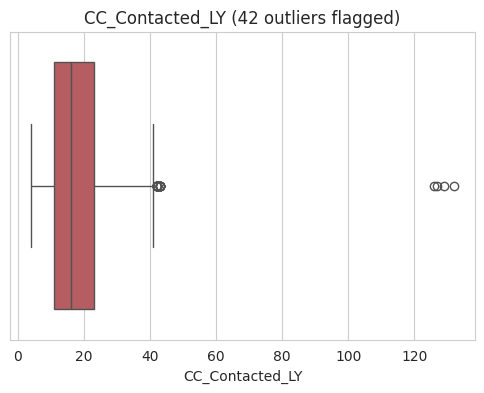

In [16]:
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper


outlier_mask, lower, upper = detect_outliers_iqr(clean_df["CC_Contacted_LY"].dropna())
print(f"CC_Contacted_LY outliers: {outlier_mask.sum()} rows "
      f"(valid range ≈ [{lower:.1f}, {upper:.1f}])")

plt.figure(figsize=(6, 4))
sns.boxplot(x=clean_df["CC_Contacted_LY"], color="#C44E52")
plt.title(f"CC_Contacted_LY ({outlier_mask.sum()} outliers flagged)")
plt.show()

**Decision:** these high-contact-count accounts are unusual but plausible
(a handful of customers who called support 100+ times in a year) rather than
obvious data-entry errors — we'll **keep** them, since a churn model should
arguably learn that extremely high support-contact volume IS a genuine churn
risk signal, not noise to be removed.

## 5. Feature Engineering

### 5.1 Drop Non-Predictive Identifier Columns

In [17]:
# AccountID is a unique identifier with no predictive value - drop it
model_df = clean_df.drop(columns=["AccountID"])
print(f"Shape after dropping AccountID: {model_df.shape}")

Shape after dropping AccountID: (11260, 18)


### 5.2 Separate Features and Target

In [18]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)

Numeric features (12): ['Tenure', 'City_Tier', 'CC_Contacted_LY', 'Service_Score', 'Account_user_count', 'CC_Agent_Score', 'rev_per_month', 'Complain_ly', 'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback']
Categorical features (5): ['Payment', 'Gender', 'account_segment', 'Marital_Status', 'Login_device']


### 5.3 Train/Test Split BEFORE Imputing or Scaling

Doing the split first, then fitting imputers/scalers only on the training
data, prevents information from the test set leaking into preprocessing
statistics — the same discipline from Days 1-2.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Training rows: {len(X_train)}  |  Testing rows: {len(X_test)}")
print(f"Training churn rate: {y_train.mean()*100:.1f}%  |  Testing churn rate: {y_test.mean()*100:.1f}%")

Training rows: 9008  |  Testing rows: 2252
Training churn rate: 16.8%  |  Testing churn rate: 16.8%


### 5.4 Impute Missing Values (Fit on Training Data Only)

In [20]:
# ── Numeric imputation: median (fit on train, applied to both) ───────────────
numeric_imputer = SimpleImputer(strategy="median")
X_train[numeric_features] = numeric_imputer.fit_transform(X_train[numeric_features])
X_test[numeric_features] = numeric_imputer.transform(X_test[numeric_features])

# ── Categorical imputation: most frequent category ───────────────────────────
categorical_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_features] = categorical_imputer.fit_transform(X_train[categorical_features])
X_test[categorical_features] = categorical_imputer.transform(X_test[categorical_features])

print("Remaining missing values in training set:", X_train.isnull().sum().sum())
print("Remaining missing values in testing set :", X_test.isnull().sum().sum())

Remaining missing values in training set: 0
Remaining missing values in testing set : 0


### 5.5 One-Hot Encode Categorical Features

In [21]:
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align columns in case a rare category only appears in one split
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)

print(f"Feature count after encoding: {X_train_encoded.shape[1]}")
print("Sample of encoded columns:", list(X_train_encoded.columns[-8:]))

Feature count after encoding: 24
Sample of encoded columns: ['Gender_Male', 'account_segment_Regular', 'account_segment_Regular Plus', 'account_segment_Super', 'account_segment_Super Plus', 'Marital_Status_Married', 'Marital_Status_Single', 'Login_device_Mobile']


### 5.6 Feature Scaling

Logistic Regression in scikit-learn applies L2 regularization by default,
which is scale-sensitive — so unlike Decision Trees (Day 4), scaling matters
here.

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Scaling complete.")
print(f"Mean of scaled training features (should be ≈0): {X_train_scaled.mean():.4f}")
print(f"Std of scaled training features (should be ≈1) : {X_train_scaled.std():.4f}")

Scaling complete.
Mean of scaled training features (should be ≈0): -0.0000
Std of scaled training features (should be ≈1) : 1.0000


## 6. Model Training — Logistic Regression

In [23]:
log_reg_model = LogisticRegression(random_state=SEED, max_iter=5000, class_weight=None)
log_reg_model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 7. Model Evaluation — The Full Classification Metrics Suite

**Business framing before we look at numbers:** in churn prediction, a
**False Negative** (predicting "will stay" for a customer who actually
churns) means we silently lose that customer and their future revenue. A
**False Positive** (predicting "will churn" for a customer who actually
stays) just means we send them a retention offer they didn't strictly need —
a much smaller cost. This means **Recall** (catching real churners) usually
matters more than Precision here — the same "minimize Type II error"
priority we saw in the cancer-screening example, now in a business context.

In [24]:
y_pred = log_reg_model.predict(X_test_scaled)
y_pred_proba = log_reg_model.predict_proba(X_test_scaled)[:, 1]  # P(churn)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}  <- how many real churners we actually caught")
print(f"F1-Score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

Accuracy : 0.8837
Precision: 0.7532
Recall   : 0.4591  <- how many real churners we actually caught
F1-Score : 0.5705
AUC-ROC  : 0.8670

Full classification report:
              precision    recall  f1-score   support

    Retained       0.90      0.97      0.93      1873
     Churned       0.75      0.46      0.57       379

    accuracy                           0.88      2252
   macro avg       0.83      0.71      0.75      2252
weighted avg       0.87      0.88      0.87      2252



Confusion Matrix (positive class = Churned):
                  Predicted Churn   Predicted Retained
Actual Churn           TP = 174              FN = 205
Actual Retained        FP = 57               TN = 1816


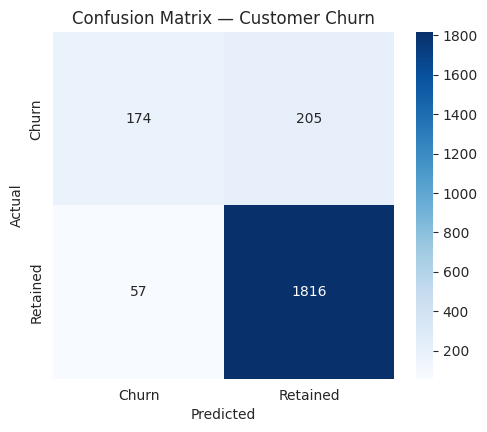


Type I error rate  (alpha, false retention-offer rate) = 0.0304
Type II error rate (beta, missed-churner rate)          = 0.5409
Statistical Power (1-beta) = Recall                     = 0.4591


In [25]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # churn=1 as positive, listed first
TP, FN, FP, TN = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

print("Confusion Matrix (positive class = Churned):")
print(f"                  Predicted Churn   Predicted Retained")
print(f"Actual Churn           TP = {TP}              FN = {FN}")
print(f"Actual Retained        FP = {FP}               TN = {TN}")

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Churn", "Retained"], yticklabels=["Churn", "Retained"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Customer Churn")
plt.show()

alpha = FP / (FP + TN)   # Type I error rate
beta = FN / (FN + TP)    # Type II error rate
print(f"\nType I error rate  (alpha, false retention-offer rate) = {alpha:.4f}")
print(f"Type II error rate (beta, missed-churner rate)          = {beta:.4f}")
print(f"Statistical Power (1-beta) = Recall                     = {1-beta:.4f}")

## 8. ROC Curve & AUC

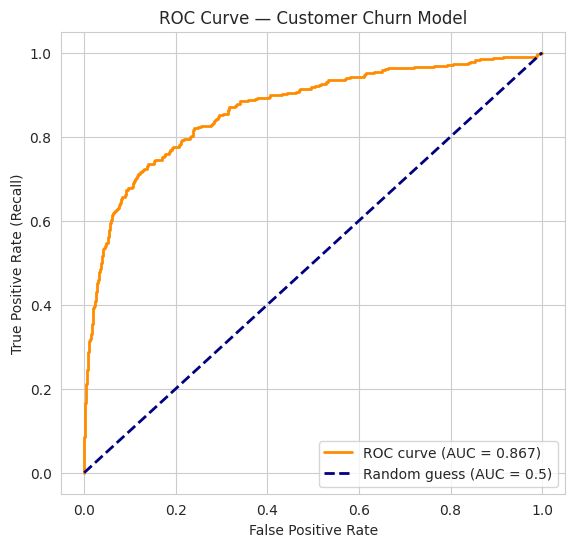

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Customer Churn Model")
plt.legend(loc="lower right")
plt.show()

## 8b. Improving Recall — class_weight='balanced'

The default model above only caught 46% of real churners — not because
Logistic Regression is incapable of better, but because with an 83/17 class
imbalance, the model has little incentive to work hard on the minority
(churn) class. `class_weight='balanced'` fixes this by penalizing a
misclassified churner more heavily during training, roughly in proportion to
how rare that class is.

In [27]:
# ── Retrain with class_weight='balanced' - one parameter, big effect ─────────
log_reg_balanced = LogisticRegression(random_state=SEED, max_iter=5000, class_weight="balanced")
log_reg_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = log_reg_balanced.predict(X_test_scaled)

print("Comparison: default vs class_weight='balanced'")
comparison_cw = pd.DataFrame({
    "Default": {
        "Recall": round(recall_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3),
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
    },
    "class_weight='balanced'": {
        "Recall": round(recall_score(y_test, y_pred_balanced), 3),
        "Precision": round(precision_score(y_test, y_pred_balanced), 3),
        "F1": round(f1_score(y_test, y_pred_balanced), 3),
        "Accuracy": round(accuracy_score(y_test, y_pred_balanced), 3),
    },
})
display(comparison_cw)

print("\nRecall nearly doubles - but precision drops in exchange. This is a real")
print("trade-off, not a free upgrade: more true churners get caught, but also")
print("more unnecessary retention offers get sent to customers who'd have stayed.")
print("Whether this trade is worth it depends on the actual dollar cost of a")
print("missed churner vs. an unneeded retention offer for this business.")

# Use the balanced model's probabilities for the threshold sweep below
y_pred_proba = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]

Comparison: default vs class_weight='balanced'


,Default,class_weight='balanced'
Recall,0.459,0.813
Precision,0.753,0.393
F1,0.570,0.530
Accuracy,0.884,0.757



Recall nearly doubles - but precision drops in exchange. This is a real
trade-off, not a free upgrade: more true churners get caught, but also
more unnecessary retention offers get sent to customers who'd have stayed.
Whether this trade is worth it depends on the actual dollar cost of a
missed churner vs. an unneeded retention offer for this business.


## 9. Threshold Tuning — Prioritizing Recall for a Retention Campaign

Since missing a real churner is costlier than an unnecessary retention offer,
let's see what happens if we lower the classification threshold below 0.5.

In [28]:
def evaluate_at_threshold(y_true, y_proba, threshold):
    y_pred_t = (y_proba >= threshold).astype(int)
    cm_t = confusion_matrix(y_true, y_pred_t, labels=[1, 0])
    tp, fn, fp, tn = cm_t[0, 0], cm_t[0, 1], cm_t[1, 0], cm_t[1, 1]
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return {"threshold": threshold, "TP": tp, "FN": fn, "FP": fp, "TN": tn,
            "precision": round(precision_t, 3), "recall": round(recall_t, 3)}


threshold_results = [evaluate_at_threshold(y_test, y_pred_proba, t) for t in [0.2, 0.3, 0.4, 0.5, 0.6]]
display(pd.DataFrame(threshold_results))

print("\nLowering the threshold catches more real churners (higher recall) at the")
print("cost of more unnecessary retention offers (lower precision) - a deliberate")
print("business trade-off, not a modeling mistake.")

,threshold,TP,FN,FP,TN,precision,recall
0,0.2,354,25,1178,695,0.231,0.934
1,0.3,345,34,863,1010,0.286,0.910
2,0.4,323,56,640,1233,0.335,0.852
3,0.5,308,71,476,1397,0.393,0.813
4,0.6,278,101,337,1536,0.452,0.734



Lowering the threshold catches more real churners (higher recall) at the
cost of more unnecessary retention offers (lower precision) - a deliberate
business trade-off, not a modeling mistake.


## 10. Interpret the Model — Which Factors Drive Churn?

In [29]:
coefficients_df = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Coefficient": log_reg_model.coef_[0]
})
coefficients_df["Odds_Ratio"] = np.exp(coefficients_df["Coefficient"])
coefficients_df = coefficients_df.sort_values("Coefficient", key=abs, ascending=False)

print("Top 10 features most associated with churn (sorted by impact):")
display(coefficients_df.head(10))

print("\nInterpretation: a positive coefficient (Odds_Ratio > 1) means that feature")
print("INCREASES the odds of churn; a negative coefficient (Odds_Ratio < 1) means")
print("it DECREASES the odds of churn, holding everything else constant.")

Top 10 features most associated with churn (sorted by impact):


,Feature,Coefficient,Odds_Ratio
0,Tenure,-1.441,0.237
7,Complain_ly,0.704,2.022
19,account_segment_Super,-0.446,0.640
5,CC_Agent_Score,0.372,1.451
22,Marital_Status_Single,0.334,1.397
4,Account_user_count,0.328,1.388
1,City_Tier,0.316,1.372
10,Day_Since_CC_connect,-0.306,0.736
2,CC_Contacted_LY,0.292,1.339
12,Payment_Credit Card,-0.290,0.748



Interpretation: a positive coefficient (Odds_Ratio > 1) means that feature
INCREASES the odds of churn; a negative coefficient (Odds_Ratio < 1) means
it DECREASES the odds of churn, holding everything else constant.


**Business takeaway:** whichever features top this list (commonly things
like recent complaints, low tenure, or a specific account segment) are exactly
where a retention team should focus outreach — this coefficient table turns a
statistical model into a concrete, actionable business recommendation.

## Session Recap

- **Package setup** — every library declared up front, with clear error handling
- **Data understanding** — read the metadata sheet before touching the data
- **Deep EDA** — missing values, class imbalance, discovering hidden junk
  characters in "numeric" columns, inconsistent category spellings, churn-rate
  breakdowns by category, and outlier checks
- **Cleaning** — every fix was a documented decision, not a silent guess
- **Feature engineering** — split-then-impute-then-encode-then-scale, in that
  order, to avoid data leakage
- **Logistic Regression** — trained, evaluated with the FULL classification
  metrics suite (not just accuracy), framed around the real business cost of
  Type I vs Type II errors in a churn context
- **Threshold tuning & coefficient interpretation** — turning the model into
  an actionable retention strategy, not just a number on a dashboard

**Next:** the companion Day 4 notebook applies Decision Trees and Ensemble
Methods to this same dataset — compare the results.